<a href="https://colab.research.google.com/github/ExcWasHere/PCVK_2026/blob/main/Week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
cv2_imshow(img)

print("Resolusi Gambar: ", img.shape[1], " x ", img.shape[0])

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img2)

In [ ]:
import cv2
import matplotlib.pyplot as plt

img_gray = cv2.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg', cv2.IMREAD_GRAYSCALE)

#tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title("tanpa cmap boz")

#pake cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title("pakek cmap boz")

plt.show()

In [ ]:
# PERTANYAAN PRAKTIKUM GES
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

img = cv2.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
cv2_imshow(img)
plt.imshow(img)
plt.show()

print("Nilai piksel:", img[100, 100])

2. perbedaannya terletak pada bit dan pengaruhnya adalah int32 menyimpan rentang nilai int lebih besar dripada int 16

3. untuk mengimpor cv2_imshow() dari google colab agar citra OpenCV dapat ditampilkan di output notebook

4. sama-sama menampilkan citra dengan urutan kanal RGB sehingga warna yang ditampilkan merupakan warna sebenarnya. Perbedaannya skimage.io.imread() membaca citra dalam urutan RGB, sedangkan cv2.imread() membaca citra dalam urutan BGR

5. mengubah figsize tidak mempengaruhi nilai img.shape. Nilai img.shape sebelum dan sesudah citra ditampilkan dengan figsize yang lebih besar, hasilnya tetap sama

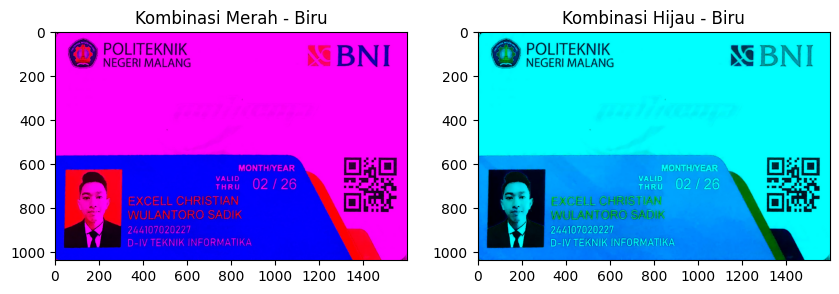

In [2]:
#penerapan 1
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = '/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg'

img = cv.imread(IMG_PATH)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_RB = img_rgb.copy()
img_RB[:, :, 1] = 0

img_GB = img_rgb.copy()
img_GB[:, :, 0] = 0

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_RB)
plt.title('Kombinasi Merah - Biru')

plt.subplot(1, 2, 2)
plt.imshow(img_GB)
plt.title('Kombinasi Hijau - Biru')
plt.show()

In [ ]:
#penerapan 2
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = '/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg'

img = cv.imread(IMG_PATH)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_vh = cv.flip(img_rgb, -1)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(flip_v)
plt.title('a) Cerminan Vertikal')

plt.subplot(1, 3, 2)
plt.imshow(flip_h)
plt.title('b) Cerminan Horizontal')

plt.subplot(1, 3, 3)
plt.imshow(flip_vh)
plt.title('c) Cerminan Vertikal + Horizontal')
plt.show()

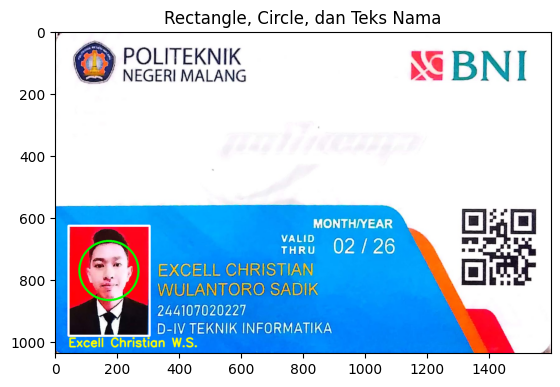

In [14]:
#penerapan 3
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

IMG_PATH = '/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg'

img = cv.imread(IMG_PATH)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_draw = img_rgb.copy()

pt1, pt2 = (43, 626), (304, 980)
center, radius = (173, 770), 95

cv.rectangle(img_draw, pt1, pt2, color=(255, 255, 255), thickness=6)
cv.circle(img_draw, center, radius, color=(0, 255, 0), thickness=5)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_draw, text='Excell Christian W.S.', org=(43, 1015), fontFace=font, fontScale=1.3, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)

plt.imshow(img_draw)
plt.title('Rectangle, Circle, dan Teks Nama')
plt.show()

In [ ]:
# studi kacus 1
def tambah_label(img_bgr, teks):
    h, w = img_bgr.shape[:2]
    tinggi_bar = h // 12
    canvas = img_bgr.copy()
    canvas[h - tinggi_bar:h, 0:w] = (0, 0, 0)

    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = tinggi_bar / 40
    thickness = max(1, tinggi_bar // 25)
    org = (10, h - tinggi_bar // 3)

    cv.putText(canvas, teks, org, font, font_scale, (255, 255, 255),
               thickness, lineType=cv.LINE_AA)
    return canvas

img_landscape = cv.imread(IMG_PATH)
img_potrait = img_landscape[:, 0:400].copy()

hasil1 = tambah_label(img_landscape, 'PCVK 2026')
hasil2 = tambah_label(img_potrait, 'PCVK 2026')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(hasil1, cv.COLOR_BGR2RGB))
plt.title(f'Lanskap ({img_landscape.shape[1]}x{img_landscape.shape[0]})')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(hasil2, cv.COLOR_BGR2RGB))
plt.title(f'Potrait ({img_potrait.shape[1]}x{img_potrait.shape[0]})')

plt.show()

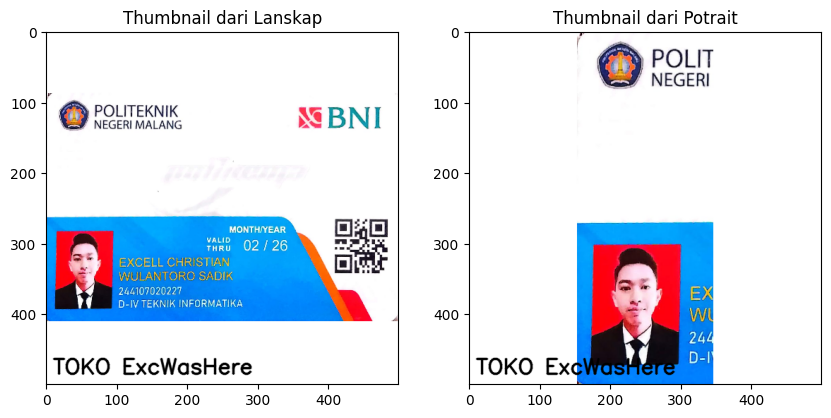

In [18]:
# studi kasus 2
def buat_thumbnail_persegi(img_bgr, ukuran=500, warna_bg=(255, 255, 255), nama_toko='TOKO ExcWasHere'):
    h, w = img_bgr.shape[:2]
    skala = ukuran / max(h, w)
    w_baru, h_baru = int(w * skala), int(h * skala)
    img_resize = cv.resize(img_bgr, (w_baru, h_baru))
    canvas = np.full((ukuran, ukuran, 3), warna_bg, dtype=np.uint8)

    x_offset = (ukuran - w_baru) // 2
    y_offset = (ukuran - h_baru) // 2
    canvas[y_offset:y_offset + h_baru, x_offset:x_offset + w_baru] = img_resize
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = ukuran / 500
    thickness = max(1, ukuran // 250)
    cv.putText(canvas, nama_toko, (10, ukuran - 15), font, font_scale,
               (0, 0, 0), thickness, lineType=cv.LINE_AA)

    return canvas

thumb1 = buat_thumbnail_persegi(img_landscape)
thumb2 = buat_thumbnail_persegi(img_potrait)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(thumb1, cv.COLOR_BGR2RGB))
plt.title('Thumbnail dari Lanskap')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(thumb2, cv.COLOR_BGR2RGB))
plt.title('Thumbnail dari Potrait')
plt.show()